In [1]:
#===========================================
# Import Library
#===========================================

import jax
import jax.numpy as jnp
import jax.scipy as jsp
import jax.random as jrandom
jax.config.update("jax_enable_x64", True) # Enable Float64 for more stable matrix inversions.
import blackjax

import gpjax as gpx
from tensorflow_probability.substrates import jax as tfp
from tensorflow_probability.substrates.jax import distributions as dist
from tensorflow_probability.substrates.jax.mcmc import sample_halton_sequence

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pandas as pd

import sys
sys.path.append("..")
from src import GP, GPBanditSampler, HaltonSequence, MMD, TVD, MCMC


/opt/homebrew/anaconda3/lib/python3.11/site-packages/cola/backends/backends.py:75: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(cls, tree_flatten, tree_unflatten)


In [2]:
#===========================================
# Target Density
#===========================================

Srho = jnp.array([[1.0, 0.9], [0.9, 1.0]])
Srho_inv = jnp.linalg.inv(Srho)

@jax.jit
def log_density(x):
    return - ((x @ Srho_inv) @ x) / 2.0

log_density_vmap = jax.vmap(log_density)


In [3]:
#===========================================
# Excute
#===========================================

key = jrandom.key(0)
key, _key = jax.random.split(key)
bounds = ( jnp.array([-4, -4]), jnp.array([4, 4]) )
halton = HaltonSequence(dim=2, bounds=bounds, rngkey=_key)
bandit = GPBanditSampler(n_init=1, n_eval=170, sequence=halton)

X = halton.generate(jnp.arange(1))
y = jnp.array([log_density(x) for x in X])
w = jnp.exp( y - jsp.special.logsumexp( y ) )

for ith in range(1, 30):
    #====== fit GP ======
    gp_mean = lambda x: - 20.0
    gp_kernel = gpx.kernels.RBF(n_dims=2, lengthscale=jnp.array([1.0, 1.0]), variance=jnp.array([5.0]))
    gp = GP(gp_mean, gp_kernel)
    key, _key = jax.random.split(key)
    gp.tune_kernel_parameter(X, y, rng_key=_key)
    gp.fit(X, y)
    posterior_mean = jax.vmap(gp.posterior_mean, in_axes=0, out_axes=0)
    posterior_scale = jax.vmap(gp.posterior_scale, in_axes=0, out_axes=0)
    objective = jax.vmap(gp.jensen_exp, in_axes=0, out_axes=0)
    #====================
    
    #====== fit KH ======
    X_new = bandit.find(objective)
    y_new = log_density(X_new)
    #====================
    
    #=== Stack point ====
    X = jnp.vstack((X, X_new))
    y = jnp.hstack((y, y_new))
    w = jnp.exp( y - jsp.special.logsumexp( y ) )
    #====================


  0%|          | 0/1000 [00:00<?, ?it/s]

/opt/homebrew/anaconda3/lib/python3.11/site-packages/cola/backends/backends.py:75: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(cls, tree_flatten, tree_unflatten)
/opt/homebrew/anaconda3/lib/python3.11/site-packages/cola/backends/backends.py:75: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(cls, tree_flatten, tree_unflatten)


  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

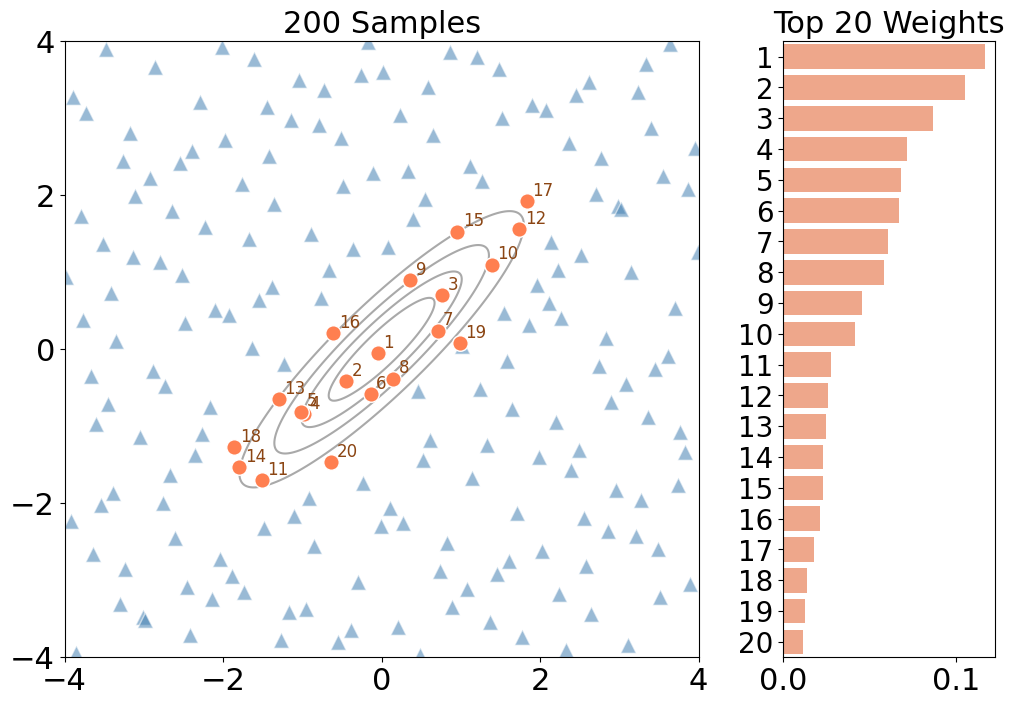

In [14]:
#===========================================
# Visualise Samples
#===========================================

def plot_sample(X, df, bounds=((-10,-10), (10,10))):
    fig, axs = plt.subplots(1, 2, figsize=(12, 8), gridspec_kw={'width_ratios': [3, 1]})
    
    n_grids = 500
    plt_x = jnp.linspace(bounds[0][0], bounds[1][0], n_grids)
    plt_y = jnp.linspace(bounds[0][1], bounds[1][1], n_grids)
    plt_x_, plt_y_ = jnp.meshgrid(plt_x, plt_y)
    plt_z = jnp.c_[ plt_x_.flatten(), plt_y_.flatten() ]
    exp_p = jnp.exp( log_density_vmap(plt_z) ).reshape((n_grids, n_grids))
    
    idx = df.iloc[20:200]["index"].to_numpy()
    axs[0].scatter(X[idx,0], X[idx,1], label="Samples", s=125, marker="^", color='steelblue', alpha=0.55, edgecolor="white", zorder=2)   
    idx = df.iloc[0:20]["index"].to_numpy()
    axs[0].scatter(X[idx,0], X[idx,1], label="Samples", s=125, marker="o", color='coral', edgecolor="white", zorder=3)   
    axs[0].contour(plt_x_, plt_y_, exp_p, levels=5, colors='darkgray', zorder=1)
    axs[0].set_xlim(bounds[0][0], bounds[1][0])
    axs[0].set_ylim(bounds[0][1], bounds[1][1])
    axs[0].tick_params(axis='both', which='major', labelsize=22)
    axs[0].set_title('200 Samples', fontsize=22)
    axs[0].yaxis.set_major_locator(ticker.MultipleLocator(2))
    
    df_head = df.head(20)
    sns.barplot(df_head, x="weight", y="name", color="lightsalmon", ax=axs[1])
    axs[1].set_xlabel("")
    axs[1].set_ylabel("")
    axs[1].tick_params(axis='x', which='major', labelsize=22)
    axs[1].tick_params(axis='y', which='major', labelsize=20)
    axs[1].set_title('Top 20 Weights', fontsize=22)
    
    df_head.reset_index(drop=True, inplace=True)
    for i, row in df_head.iterrows():
        idx = row["index"]
        axs[0].text(X[idx,0]+0.07, X[idx,1]+0.07, str(i+1), fontsize=12, color="saddlebrown")

X_all = jnp.vstack((X, bandit.points_candidate))
y_all = log_density_vmap(X_all)
w_all = jnp.exp( y_all - jsp.special.logsumexp( y_all ) )
names = [r"$\theta_{"+"{:03d}".format(i)+r"}$" for i in range(1, w_all.shape[0]+1)]
df_all = pd.DataFrame({"index": jnp.arange(200), "weight": w_all, "name": names})
df_all = df_all.sort_values(by="weight", ascending=False)
df_all["name"] = ["{:d}".format(i+1) for i in range(len(df_all))]

plot_sample(X_all, df_all, bounds=bounds)


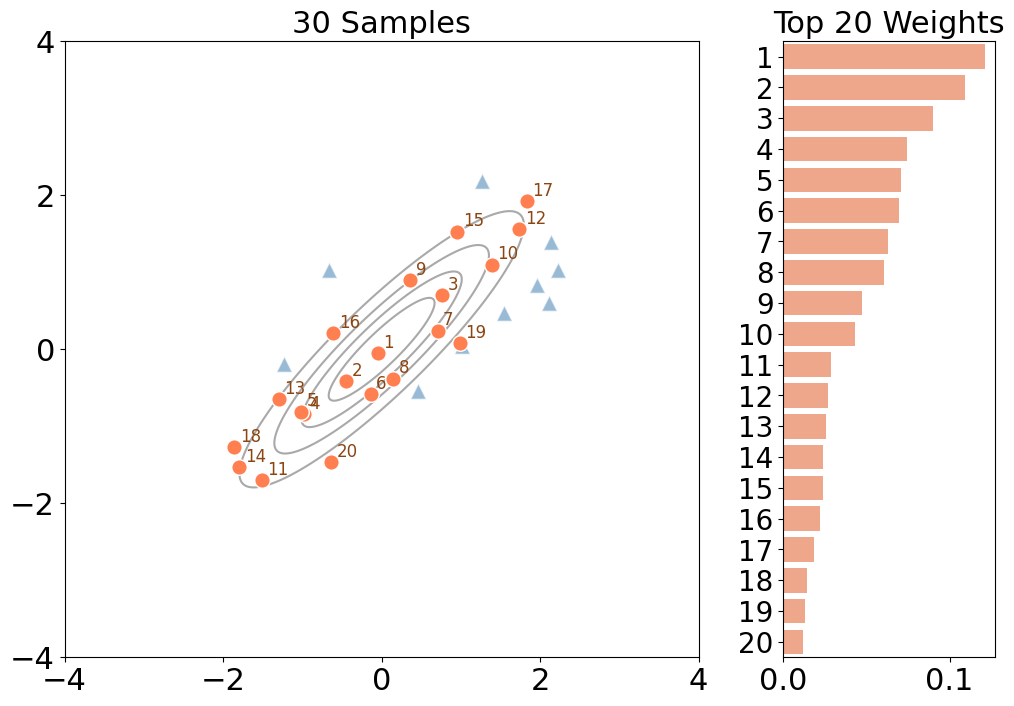

In [6]:
#===========================================
# Visualise Samples
#===========================================

def plot_sample(X, df, bounds=((-10,-10), (10,10))):
    fig, axs = plt.subplots(1, 2, figsize=(12, 8), gridspec_kw={'width_ratios': [3, 1]})  
    
    n_grids = 500
    plt_x = jnp.linspace(bounds[0][0], bounds[1][0], n_grids)
    plt_y = jnp.linspace(bounds[0][1], bounds[1][1], n_grids)
    plt_x_, plt_y_ = jnp.meshgrid(plt_x, plt_y)
    plt_z = jnp.c_[ plt_x_.flatten(), plt_y_.flatten() ]
    exp_p = jnp.exp( log_density_vmap(plt_z) ).reshape((n_grids, n_grids))
    
    flags = df["flags"].to_numpy()
    order = df["index"].to_numpy()
    axs[0].contour(plt_x_, plt_y_, exp_p, levels=5, colors='darkgray', zorder=1)
    axs[0].scatter(X[order][flags==1,0], X[order][flags==1,1], s=125, marker="o", color='coral', edgecolor="white", zorder=3)
    axs[0].scatter(X[order][flags==0,0], X[order][flags==0,1], s=125, marker="^", color='steelblue', alpha=0.55, edgecolor="white", zorder=2)   
    axs[0].set_xlim(bounds[0][0], bounds[1][0])
    axs[0].set_ylim(bounds[0][1], bounds[1][1])
    axs[0].tick_params(axis='both', which='major', labelsize=22)
    axs[0].set_title('30 Samples', fontsize=22)
    axs[0].yaxis.set_major_locator(ticker.MultipleLocator(2))
    
    df_head = df.head(20)
    palette = [ 'lightsalmon' if flag == 1 else 'forestgreen' for flag in df.head(20)["flags"].to_numpy() ]
    sns.barplot(df_head, x="weight", y="name", palette=palette, ax=axs[1])
    axs[1].set_xlabel("")
    axs[1].set_ylabel("")
    axs[1].tick_params(axis='x', which='major', labelsize=22)
    axs[1].tick_params(axis='y', which='major', labelsize=20)
    axs[1].set_title('Top 20 Weights', fontsize=22)
    
    df_head.reset_index(drop=True, inplace=True)
    for i, row in df_head.iterrows():
        idx = row["index"]
        axs[0].text(X[idx,0]+0.07, X[idx,1]+0.07, str(i+1), fontsize=12, color="saddlebrown")

idx20 = df_all.head(20)["index"].to_list()
flags = jnp.array([ 1 if any((X_all[idx20,:]==X[i]).all(1)) else 0 for i in range(X.shape[0]) ], dtype=int)
label = [ names[int(jnp.argwhere((X_all==X[i]).all(1))[0][0])] for i in range(X.shape[0]) ]
df = pd.DataFrame({"index": jnp.arange(X.shape[0]), "weight": w, "name": label, "flags": flags})
df = df.sort_values(by="weight", ascending=False)
df["name"] = ["{:d}".format(i+1) for i in range(len(df))]

plot_sample(X, df, bounds=bounds)
